# Architecture 1 (Enhanced Features): BioClinicalBERT + XGBoost Fusion

**Combines:**
- **Feature set:** Architecture 3 — 31 structured features including NEWS2, qSOFA, MEWS clinical scores
- **Model:** Architecture 1 v4 — mean-pooled BioClinicalBERT + 5-fold XGBoost probs, two-phase training

**Input:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_features.csv`  
**Output:** `s3://ed-triage-capstone-group7/models/arch1_enhanced_features/`

| Section | Content |
|---------|----------|
| 1 | Setup & installs |
| 2 | Imports & config |
| 3 | Load data from S3 |
| 4 | Feature selection, text construction, train/val/test split |
| 5 | Structured feature pipeline (transform_structured with clinical scores) |
| 6 | XGBoost stage 1 — 5-fold cross-fitting |
| 7 | Dataset & DataLoader |
| 8 | Model definition (MeanPoolHybridModel) |
| 9 | Training loop (two-phase: head warmup → BERT fine-tune) |
| 10 | Training curves |
| 11 | Evaluation on test set |
| 12 | Save artifacts to S3 |

## 1. Setup & Installs

In [2]:
# Install dependencies not pre-installed in the PyTorch SageMaker image
!pip install -q boto3 transformers xgboost scikit-learn joblib "numpy==1.26.4"

## 2. Imports & Config

In [3]:
import io
import json
import math
import random
import warnings

import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── AWS / S3 Config ────────────────────────────────────────────────────────────
S3_BUCKET    = "ed-triage-capstone-group7"
DATA_KEY     = "Data_Output/consolidated_dataset_features.csv"
SPLIT_PREFIX = "Data_Output/splits/arch1_enhanced/"
MODEL_PREFIX = "models/arch1_enhanced_features/"
BERT_MODEL   = "emilyalsentzer/Bio_ClinicalBERT"

# ── Model / Training Hyperparameters (from arch1_v4) ──────────────────────────
NUM_CLASSES        = 3
MAX_LEN            = 384
BATCH_SIZE         = 16
ACCUMULATION_STEPS = 2
HEAD_WARMUP_EPOCHS = 1
FINETUNE_EPOCHS    = 20
PATIENCE           = 5
HEAD_LR            = 2e-4
BERT_BASE_LR       = 6e-6
FUSION_LR          = 1.5e-4
LR_DECAY           = 0.80
UNFREEZE_LAYERS    = 3
LABEL_SMOOTHING    = 0.0
FUSION_HIDDEN_DIM  = 96
FUSION_DROPOUT     = 0.55

# ── Device ────────────────────────────────────────────────────────────────────
AMP_DTYPE       = torch.float16
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUTOCAST_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
scaler          = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Load Data from S3

In [4]:
s3  = boto3.client("s3", region_name="us-east-1")
obj = s3.get_object(Bucket=S3_BUCKET, Key=DATA_KEY)
df  = pd.read_csv(io.BytesIO(obj["Body"].read()))

print(f"Loaded: {df.shape}")
print(f"\nTriage distribution (raw 4-class):")
print(df["triage"].value_counts().sort_index().rename(
    {1: "L1-Critical", 2: "L2-Emergent", 3: "L3-Urgent", 4: "L4-LessUrgent"}
).to_string())

Loaded: (8383, 66)

Triage distribution (raw 4-class):
triage
L1-Critical       502
L2-Emergent      3100
L3-Urgent        4724
L4-LessUrgent      57


## 4. Feature Selection, Text Construction & Split

In [5]:
# ── Acute-focused text (arch1_v4 / arch3 pattern) ─────────────────────────────
# CC: 24 words, HPI: 160 words, PMH: 40 words — keeps BERT input compact

def clip_words(text, max_words):
    text = "" if pd.isna(text) else str(text).replace("\n", " ").strip()
    return " ".join(text.split()[:max_words]) if text else ""


def build_triage_text(row):
    cc  = clip_words(row["chiefcomplaint"], 24)
    hpi = clip_words(row["HPI"], 160)
    pmh = clip_words(row["past_medical_history"], 40)
    parts = []
    if cc:  parts.append(f"Chief complaint: {cc}.")
    if hpi: parts.append(f"History: {hpi}.")
    if pmh: parts.append(f"PMH: {pmh}.")
    return " ".join(parts)


# 4-class → 3-class collapse (L4 merged into L3, same as arch1_v4)
target_map = {1: 0, 2: 1, 3: 2, 4: 2}
df["triage_3class"]        = df["triage"].map(target_map).astype(int)
df["triage_text"]          = df.apply(build_triage_text, axis=1)
df["triage_text_word_count"] = df["triage_text"].str.split().str.len().astype(int)
df["pmh_has_content"]      = df["past_medical_history"].fillna("").str.strip().ne("").astype(int)

CLASS_NAMES = ["L1-Critical", "L2-Emergent", "L3-Urgent/LessUrgent"]

print("3-class distribution:")
print(df["triage_3class"].value_counts().sort_index().rename(
    {0: CLASS_NAMES[0], 1: CLASS_NAMES[1], 2: CLASS_NAMES[2]}
).to_string())
print()
print(f"triage_text — 50th percentile: {df['triage_text_word_count'].quantile(0.50):.0f} words")
print(f"triage_text — 90th percentile: {df['triage_text_word_count'].quantile(0.90):.0f} words")

3-class distribution:
triage_3class
L1-Critical              502
L2-Emergent             3100
L3-Urgent/LessUrgent    4781

triage_text — 50th percentile: 135 words
triage_text — 90th percentile: 198 words


In [6]:
# ── Base columns loaded from CSV (raw inputs to transform_structured) ──────────
BASE_COLUMNS = [
    "stay_id", "triage", "triage_3class",
    "triage_text", "triage_text_word_count", "pmh_has_content",
    "chiefcomplaint", "HPI", "past_medical_history", "arrival_transport",
    "pain", "pain_missing", "age",
    "temp_f", "heart_rate", "resp_rate", "spo2", "sbp", "dbp",
    "vitals_any_missing", "vitals_out_of_range",
]

X = df[BASE_COLUMNS].copy()
y = df["triage_3class"].values

# ── Stratified 80 / 10 / 10 split ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

for frame, target in [(X_train, y_train), (X_val, y_val), (X_test, y_test)]:
    frame["triage_3class"] = target

total = len(df)
print(f"Train: {len(X_train)} ({len(X_train)/total:.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/total:.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/total:.1%})")
print()
print("Train class counts:")
print(pd.Series(y_train).value_counts().sort_index().rename(
    {0: CLASS_NAMES[0], 1: CLASS_NAMES[1], 2: CLASS_NAMES[2]}
).to_string())

# ── Save splits to S3 ──────────────────────────────────────────────────────────
def save_split_to_s3(split_df, y_split, key):
    out = split_df.copy()
    out["triage_3class"] = y_split
    buf = io.BytesIO()
    out.to_csv(buf, index=False)
    buf.seek(0)
    s3.put_object(Bucket=S3_BUCKET, Key=key, Body=buf.getvalue(), ContentType="text/csv")
    print(f"  Saved → s3://{S3_BUCKET}/{key}  ({len(out)} rows)")

print("\nSaving splits:")
save_split_to_s3(X_train, y_train, f"{SPLIT_PREFIX}train.csv")
save_split_to_s3(X_val,   y_val,   f"{SPLIT_PREFIX}val.csv")
save_split_to_s3(X_test,  y_test,  f"{SPLIT_PREFIX}test.csv")

Train: 6706 (80.0%)
Val:   838 (10.0%)
Test:  839 (10.0%)

Train class counts:
L1-Critical              402
L2-Emergent             2480
L3-Urgent/LessUrgent    3824

Saving splits:
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch1_enhanced/train.csv  (6706 rows)
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch1_enhanced/val.csv  (838 rows)
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch1_enhanced/test.csv  (839 rows)


## 5. Structured Feature Pipeline

**31 features** (Architecture 3 set), computed inline using train-split stats only.
Includes NEWS2, qSOFA, MEWS clinical early warning scores.

In [7]:
RAW_VITALS = ["temp_f", "heart_rate", "resp_rate", "spo2", "sbp", "dbp"]
CLIP_BOUNDS = {
    "temp_f":     (85.0, 115.0),
    "heart_rate": (20.0, 250.0),
    "resp_rate":  (4.0,  60.0),
    "spo2":       (50.0, 100.0),
    "sbp":        (40.0, 300.0),
    "dbp":        (10.0, 200.0),
}
TRANSPORT_MAP = {"WALK IN": 0, "UNKNOWN": 1, "AMBULANCE": 2, "HELICOPTER": 3}
FLAG_COLUMNS = [
    "spo2_abnormal", "hr_tachycardia", "rr_tachypnea",
    "temp_fever", "temp_hypothermia", "hypotension",
]

# 31 structured features — arch3 set including clinical scores
STRUCTURED_FEATURES = [
    # Raw vitals (6)
    "temp_f", "heart_rate", "resp_rate", "spo2", "sbp", "dbp",
    # Derived vitals (3)
    "shock_index", "map", "pulse_pressure",
    # Vital flags (9)
    "spo2_abnormal", "hr_tachycardia", "rr_tachypnea",
    "temp_fever", "temp_hypothermia", "hypotension",
    "vital_abnormality_count", "vitals_any_missing", "vitals_out_of_range",
    # Clinical early warning scores (4) — NEW vs arch1_v4
    "news2_score", "news2_risk", "qsofa_score", "mews_score",
    # Demographics (2)
    "age", "age_group",
    # Transport (1)
    "transport_ordinal",
    # Pain (4)
    "pain", "pain_missing", "pain_severity", "pain_x_transport",
    # Text metadata (2)
    "pmh_has_content", "triage_text_word_count",
]

assert len(STRUCTURED_FEATURES) == 31, f"Expected 31 features, got {len(STRUCTURED_FEATURES)}"
print(f"Structured feature count: {len(STRUCTURED_FEATURES)}")
print(f"Features: {STRUCTURED_FEATURES}")

Structured feature count: 31
Features: ['temp_f', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'dbp', 'shock_index', 'map', 'pulse_pressure', 'spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea', 'temp_fever', 'temp_hypothermia', 'hypotension', 'vital_abnormality_count', 'vitals_any_missing', 'vitals_out_of_range', 'news2_score', 'news2_risk', 'qsofa_score', 'mews_score', 'age', 'age_group', 'transport_ordinal', 'pain', 'pain_missing', 'pain_severity', 'pain_x_transport', 'pmh_has_content', 'triage_text_word_count']


In [8]:
# ── Clinical early warning score functions ─────────────────────────────────────

def compute_news2(row):
    """NEWS2 aggregate score (Scale 1). Temp in °F. No AVPU — max 15."""
    score = 0
    rr = row["resp_rate"]
    if   rr <= 8:   score += 3
    elif rr <= 11:  score += 1
    elif rr <= 20:  score += 0
    elif rr <= 24:  score += 2
    else:           score += 3
    spo2 = row["spo2"]
    if   spo2 <= 91:  score += 3
    elif spo2 <= 93:  score += 2
    elif spo2 <= 95:  score += 1
    sbp = row["sbp"]
    if   sbp <= 90:   score += 3
    elif sbp <= 100:  score += 2
    elif sbp <= 110:  score += 1
    elif sbp <= 219:  score += 0
    else:             score += 3
    hr = row["heart_rate"]
    if   hr <= 40:   score += 3
    elif hr <= 50:   score += 1
    elif hr <= 90:   score += 0
    elif hr <= 110:  score += 1
    elif hr <= 130:  score += 2
    else:            score += 3
    temp = row["temp_f"]
    if   temp <= 95.0:    score += 3   # ≤35°C
    elif temp <= 96.8:    score += 1   # 35.1–36°C
    elif temp <= 100.4:   score += 0   # 36.1–38°C
    elif temp <= 102.2:   score += 1   # 38.1–39°C
    else:                 score += 2   # ≥39.1°C
    return score


def compute_mews(row):
    """MEWS aggregate score. No AVPU — max 12."""
    score = 0
    sbp = row["sbp"]
    if   sbp < 70:    score += 3
    elif sbp < 81:    score += 2
    elif sbp < 101:   score += 1
    elif sbp < 200:   score += 0
    else:             score += 2
    hr = row["heart_rate"]
    if   hr < 40:     score += 2
    elif hr < 51:     score += 1
    elif hr < 101:    score += 0
    elif hr < 111:    score += 1
    elif hr < 130:    score += 2
    else:             score += 3
    rr = row["resp_rate"]
    if   rr < 9:      score += 2
    elif rr < 15:     score += 0
    elif rr < 21:     score += 1
    elif rr < 30:     score += 2
    else:             score += 3
    temp = row["temp_f"]
    if   temp < 95.0:    score += 2   # <35°C
    elif temp <= 101.1:  score += 0   # 35–38.4°C
    else:                score += 2   # ≥38.5°C
    return score


print("compute_news2 and compute_mews defined.")

compute_news2 and compute_mews defined.


In [9]:
# ── fit_structured_stats / transform_structured ────────────────────────────────
# All imputation stats fitted on training set only to prevent leakage.

def fit_structured_stats(train_df):
    """Compute imputation medians from training rows only."""
    return {
        "vital_medians": {col: float(train_df[col].median()) for col in RAW_VITALS},
        "pain_median":   float(train_df["pain"].median()),
        "age_median":    float(train_df["age"].median()),
    }


def transform_structured(df_in, stats):
    """Build all 31 structured features from BASE_COLUMNS using train-set stats."""
    feat = df_in.copy()

    # ── Impute + clip vitals ──────────────────────────────────────────────────
    for col in RAW_VITALS:
        feat[col] = feat[col].fillna(stats["vital_medians"][col]).clip(*CLIP_BOUNDS[col])

    feat["pain"] = feat["pain"].fillna(stats["pain_median"]).clip(0.0, 10.0)
    feat["age"]  = feat["age"].fillna(stats["age_median"]).clip(18, 120)

    feat["pain_missing"]       = feat["pain_missing"].astype(int)
    feat["vitals_any_missing"] = feat["vitals_any_missing"].astype(int)
    feat["vitals_out_of_range"]= feat["vitals_out_of_range"].astype(int)
    feat["transport_ordinal"]  = feat["arrival_transport"].map(TRANSPORT_MAP).fillna(1).astype(int)
    feat["age_group"]          = pd.cut(
        feat["age"], bins=[17, 44, 64, 79, 120], labels=[0, 1, 2, 3]
    ).astype(int)

    # ── Derived vitals ────────────────────────────────────────────────────────
    feat["shock_index"]    = (feat["heart_rate"] / feat["sbp"].replace(0, np.nan)).fillna(0.0)
    feat["map"]            = (feat["sbp"] + 2.0 * feat["dbp"]) / 3.0
    feat["pulse_pressure"] = feat["sbp"] - feat["dbp"]

    # ── Binary vital flags ────────────────────────────────────────────────────
    feat["spo2_abnormal"]    = (feat["spo2"] < 90).astype(int)
    feat["hr_tachycardia"]   = (feat["heart_rate"] > 100).astype(int)
    feat["rr_tachypnea"]     = (feat["resp_rate"] > 20).astype(int)
    feat["temp_fever"]       = (feat["temp_f"] >= 100.4).astype(int)
    feat["temp_hypothermia"] = (feat["temp_f"] < 96.8).astype(int)
    feat["hypotension"]      = (feat["sbp"] < 90).astype(int)

    feat["vital_abnormality_count"] = feat[FLAG_COLUMNS].sum(axis=1)
    feat.loc[feat["vitals_any_missing"] == 1, "vital_abnormality_count"] = -1

    # ── Pain features ─────────────────────────────────────────────────────────
    feat["pain_severity"]   = pd.cut(
        feat["pain"], bins=[-0.1, 0, 3, 6, 10], labels=[0, 1, 2, 3]
    ).astype(int)
    feat["pain_x_transport"] = feat["pain"] * feat["transport_ordinal"]

    # ── Clinical early warning scores (NEW vs arch1_v4) ───────────────────────
    feat["news2_score"] = feat.apply(compute_news2, axis=1)
    feat["news2_risk"]  = pd.cut(
        feat["news2_score"], bins=[-1, 4, 6, 99], labels=[0, 1, 2]
    ).astype(int)
    feat["qsofa_score"] = (
        (feat["resp_rate"] >= 22).astype(int) + (feat["sbp"] <= 100).astype(int)
    )
    feat["mews_score"] = feat.apply(compute_mews, axis=1)

    return feat[STRUCTURED_FEATURES].astype(np.float32)


# ── Fit on train, transform all splits ────────────────────────────────────────
structured_stats   = fit_structured_stats(X_train)
X_train_struct     = transform_structured(X_train, structured_stats)
X_val_struct       = transform_structured(X_val,   structured_stats)
X_test_struct      = transform_structured(X_test,  structured_stats)

assert not X_train_struct.isna().any().any(), "NaN in X_train_struct"
assert not X_val_struct.isna().any().any(),   "NaN in X_val_struct"
assert not X_test_struct.isna().any().any(),  "NaN in X_test_struct"

print(f"Structured feature count: {len(STRUCTURED_FEATURES)}")
print(X_train_struct.head(3))
print()
print("Training medians used for imputation:")
print(json.dumps(structured_stats, indent=2))

Structured feature count: 31
         temp_f  heart_rate  resp_rate   spo2    sbp    dbp  shock_index  \
669   97.400002        78.0       16.0   98.0  175.0  108.0     0.445714   
3177  97.400002        74.0       20.0   97.0  122.0   77.0     0.606557   
1420  99.000000        72.0       18.0  100.0  132.0   80.0     0.545455   

             map  pulse_pressure  spo2_abnormal  hr_tachycardia  rr_tachypnea  \
669   130.333328            67.0            0.0             0.0           0.0   
3177   92.000000            45.0            0.0             0.0           0.0   
1420   97.333336            52.0            0.0             0.0           0.0   

      temp_fever  temp_hypothermia  hypotension  vital_abnormality_count  \
669          0.0               0.0          0.0                      0.0   
3177         0.0               0.0          0.0                      0.0   
1420         0.0               0.0          0.0                      0.0   

      vitals_any_missing  vitals_out

## 6. XGBoost Stage 1 — 5-Fold Cross-Fitting

In [10]:
# ── Class weights (sqrt-dampened inverse frequency, from arch1_v4) ─────────────
train_counts = {int(c): int(n) for c, n in zip(*np.unique(y_train, return_counts=True))}
raw_class_weights = torch.tensor(
    [len(y_train) / (NUM_CLASSES * train_counts[c]) for c in range(NUM_CLASSES)],
    dtype=torch.float32,
)
CLASS_WEIGHTS = torch.sqrt(raw_class_weights)
print(f"Class weights (sqrt-dampened): {[round(x, 4) for x in CLASS_WEIGHTS.tolist()]}")

# ── XGBoost params (arch1_v4) ──────────────────────────────────────────────────
xgb_params = dict(
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    gamma=0.2,
    eval_metric="mlogloss",
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

sample_weight_map = {cls: max(train_counts.values()) / count for cls, count in train_counts.items()}
print(f"XGBoost sample weight map: {sample_weight_map}")

X_train_np = X_train_struct.values.astype(np.float32)
X_val_np   = X_val_struct.values.astype(np.float32)
X_test_np  = X_test_struct.values.astype(np.float32)

oof_probs        = np.zeros((len(X_train_np), NUM_CLASSES), dtype=np.float32)
val_probs_folds  = []
test_probs_folds = []
xgb_fold_models  = []
fold_rows        = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (fit_idx, hold_idx) in enumerate(skf.split(X_train_np, y_train), start=1):
    X_fit,  y_fit  = X_train_np[fit_idx],  y_train[fit_idx]
    X_hold, y_hold = X_train_np[hold_idx], y_train[hold_idx]
    sw_fit = np.array([sample_weight_map[int(l)] for l in y_fit], dtype=np.float32)

    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_fit, y_fit,
        sample_weight=sw_fit,
        eval_set=[(X_hold, y_hold)],
        verbose=False,
    )

    oof_probs[hold_idx] = xgb_model.predict_proba(X_hold)
    val_probs_folds.append(xgb_model.predict_proba(X_val_np))
    test_probs_folds.append(xgb_model.predict_proba(X_test_np))
    xgb_fold_models.append(xgb_model)

    hold_pred = oof_probs[hold_idx].argmax(axis=1)
    fold_rows.append({
        "fold": fold,
        "best_iteration":   int(xgb_model.best_iteration),
        "holdout_macro_f1": float(f1_score(y_hold, hold_pred, average="macro")),
        "holdout_size":     int(len(hold_idx)),
    })
    print(f"  Fold {fold} | best_iter={xgb_model.best_iteration} | "
          f"holdout macro-F1={fold_rows[-1]['holdout_macro_f1']:.4f}")

fold_summary = pd.DataFrame(fold_rows)
print()
print(fold_summary)

xgb_probs_train = oof_probs
xgb_probs_val   = np.mean(np.stack(val_probs_folds,  axis=0), axis=0)
xgb_probs_test  = np.mean(np.stack(test_probs_folds, axis=0), axis=0)

assert np.allclose(xgb_probs_train.sum(axis=1), 1.0, atol=1e-5)
assert np.allclose(xgb_probs_val.sum(axis=1),   1.0, atol=1e-5)
assert np.allclose(xgb_probs_test.sum(axis=1),  1.0, atol=1e-5)

print()
print("OOF train macro-F1:",  round(f1_score(y_train, xgb_probs_train.argmax(axis=1), average="macro"), 4))
print("Validation macro-F1:", round(f1_score(y_val,   xgb_probs_val.argmax(axis=1),   average="macro"), 4))
print()
print("Validation classification report (XGBoost ensemble):")
print(classification_report(
    y_val, xgb_probs_val.argmax(axis=1),
    target_names=CLASS_NAMES, zero_division=0
))

Class weights (sqrt-dampened): [2.3581, 0.9494, 0.7646]
XGBoost sample weight map: {0: 9.512437810945274, 1: 1.5419354838709678, 2: 1.0}
  Fold 1 | best_iter=486 | holdout macro-F1=0.5592
  Fold 2 | best_iter=420 | holdout macro-F1=0.5431
  Fold 3 | best_iter=490 | holdout macro-F1=0.5417
  Fold 4 | best_iter=499 | holdout macro-F1=0.5687
  Fold 5 | best_iter=499 | holdout macro-F1=0.5600

   fold  best_iteration  holdout_macro_f1  holdout_size
0     1             486          0.559224          1342
1     2             420          0.543140          1341
2     3             490          0.541697          1341
3     4             499          0.568741          1341
4     5             499          0.559987          1341

OOF train macro-F1: 0.5549
Validation macro-F1: 0.576

Validation classification report (XGBoost ensemble):
                      precision    recall  f1-score   support

         L1-Critical       0.51      0.50      0.51        50
         L2-Emergent       0.51      

## 7. Dataset & DataLoader

In [11]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


class TriageDataset(Dataset):
    """Tokenized triage_text + XGBoost OOF probabilities + label."""

    def __init__(self, frame, xgb_probs, labels, tokenizer, max_len):
        self.texts     = frame["triage_text"].tolist()
        self.xgb_probs = torch.tensor(xgb_probs, dtype=torch.float32)
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "xgb_probs":      self.xgb_probs[idx],
            "label":          self.labels[idx],
        }


train_dataset = TriageDataset(X_train, xgb_probs_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TriageDataset(X_val,   xgb_probs_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TriageDataset(X_test,  xgb_probs_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

batch = next(iter(train_loader))
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print({k: tuple(v.shape) for k, v in batch.items()})

Train batches: 420 | Val: 53 | Test: 53
Effective batch size: 32
{'input_ids': (16, 384), 'attention_mask': (16, 384), 'xgb_probs': (16, 3), 'label': (16,)}


## 8. Model Definition

`MeanPoolHybridModel` (arch1_v4): mean-pooled BioClinicalBERT (768) + XGBoost probs (3)  
→ LayerNorm → Linear(771, 96) → GELU → Dropout(0.55) → Linear(96, 3)

In [12]:
class MeanPoolHybridModel(nn.Module):
    def __init__(self, bert_model_name, xgb_dim=3, num_classes=3,
                 hidden_dim=FUSION_HIDDEN_DIM, dropout=FUSION_DROPOUT):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        bert_dim  = self.bert.config.hidden_size  # 768
        self.fusion_head = nn.Sequential(
            nn.LayerNorm(bert_dim + xgb_dim),
            nn.Linear(bert_dim + xgb_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def masked_mean_pool(self, last_hidden_state, attention_mask):
        mask   = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    def forward(self, input_ids, attention_mask, xgb_probs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = self.masked_mean_pool(bert_out.last_hidden_state, attention_mask)
        fused    = torch.cat([pooled, xgb_probs], dim=1)
        return self.fusion_head(fused)


def freeze_all_bert(model):
    for param in model.bert.parameters():
        param.requires_grad = False


def unfreeze_top_bert_layers(model, n_layers=UNFREEZE_LAYERS):
    freeze_all_bert(model)
    total_layers = len(model.bert.encoder.layer)
    for layer in model.bert.encoder.layer[total_layers - n_layers:]:
        for param in layer.parameters():
            param.requires_grad = True


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = MeanPoolHybridModel(BERT_MODEL, xgb_dim=NUM_CLASSES, num_classes=NUM_CLASSES).to(DEVICE)
model.bert.gradient_checkpointing_enable()
freeze_all_bert(model)

total_params, trainable_params = count_parameters(model)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

with torch.no_grad():
    logits = model(
        batch["input_ids"].to(DEVICE),
        batch["attention_mask"].to(DEVICE),
        batch["xgb_probs"].to(DEVICE),
    )
    print(f"Forward pass OK — logits shape: {tuple(logits.shape)}")

2026-03-15 00:18:26.071101: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 00:18:26.085000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773533906.103801     840 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773533906.109450     840 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 00:18:26.127638: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Total params:     108,386,217
Trainable params: 75,945
Forward pass OK — logits shape: (16, 3)


## 9. Training Loop

Two-phase training (arch1_v4):
- **Phase 1 (head warmup):** BERT frozen, only fusion head trains for 1 epoch at LR=2e-4
- **Phase 2 (fine-tune):** Top 3 BERT layers unfrozen with layer-wise LR decay, cosine schedule, patience=3

In [13]:
def build_head_optimizer(model):
    return AdamW([
        {"params": model.fusion_head.parameters(), "lr": HEAD_LR, "weight_decay": 0.01}
    ])


def build_finetune_optimizer(model, n_layers=UNFREEZE_LAYERS,
                             base_lr=BERT_BASE_LR, head_lr=FUSION_LR, decay=LR_DECAY):
    param_groups = [
        {"params": model.fusion_head.parameters(), "lr": head_lr, "weight_decay": 0.01}
    ]
    layers       = model.bert.encoder.layer
    total_layers = len(layers)
    selected     = list(range(total_layers - n_layers, total_layers))
    for rank, layer_idx in enumerate(selected):
        scale = decay ** (len(selected) - 1 - rank)  # lower layers get smaller LR
        param_groups.append({
            "params": layers[layer_idx].parameters(),
            "lr": base_lr * scale,
            "weight_decay": 0.01,
        })
    return AdamW(param_groups)


def build_scheduler(optimizer, num_epochs):
    steps_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
    total_steps     = steps_per_epoch * num_epochs
    warmup_steps    = max(1, int(0.10 * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    return scheduler, total_steps, warmup_steps


def optimizer_lr_snapshot(optimizer):
    return [round(g["lr"], 8) for g in optimizer.param_groups]


criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS.to(DEVICE), label_smoothing=LABEL_SMOOTHING
)
print(f"Loss: CrossEntropyLoss(weighted, label_smoothing={LABEL_SMOOTHING})")
print(f"Class weights: {[round(x, 4) for x in CLASS_WEIGHTS.tolist()]}")

Loss: CrossEntropyLoss(weighted, label_smoothing=0.0)
Class weights: [2.3581, 0.9494, 0.7646]


In [14]:
def compute_critical_f1(labels, preds):
    report = classification_report(labels, preds, labels=[0, 1, 2], output_dict=True, zero_division=0)
    return float(report["0"]["f1-score"])


def train_epoch(model, loader, optimizer, scheduler, criterion, accumulation_steps=ACCUMULATION_STEPS):
    model.train()
    total_loss = 0.0
    preds, labels = [], []
    optimizer.zero_grad()

    for step, batch in enumerate(loader, start=1):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        xgb_probs      = batch["xgb_probs"].to(DEVICE)
        target         = batch["label"].to(DEVICE)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
            logits = model(input_ids, attention_mask, xgb_probs)
            loss   = criterion(logits, target) / accumulation_steps

        scaler.scale(loss).backward()

        if step % accumulation_steps == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps
        preds.extend(logits.detach().argmax(dim=1).cpu().numpy())
        labels.extend(target.detach().cpu().numpy())

    return {
        "loss":     total_loss / len(loader),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "preds":    np.array(preds),
        "labels":   np.array(labels),
    }


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            xgb_probs      = batch["xgb_probs"].to(DEVICE)
            target         = batch["label"].to(DEVICE)

            with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(input_ids, attention_mask, xgb_probs)
                loss   = criterion(logits, target)

            total_loss += loss.item()
            preds.extend(logits.detach().argmax(dim=1).cpu().numpy())
            labels.extend(target.detach().cpu().numpy())

    return {
        "loss":        total_loss / len(loader),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "critical_f1": compute_critical_f1(labels, preds),
        "preds":       np.array(preds),
        "labels":      np.array(labels),
    }


def predict_probs(model, loader):
    model.eval()
    outputs = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            xgb_probs      = batch["xgb_probs"].to(DEVICE)
            with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(input_ids, attention_mask, xgb_probs)
            outputs.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    return np.vstack(outputs)

In [15]:
# ── Two-phase training loop ────────────────────────────────────────────────────
best_val_f1     = -1.0
bad_epochs      = 0
history         = []
global_epoch    = 0
best_model_path = "/tmp/best_model_arch1_enhanced.pt"
stop_training   = False

phase_plan = [
    ("head_warmup",            HEAD_WARMUP_EPOCHS),
    (f"top{UNFREEZE_LAYERS}_finetune", FINETUNE_EPOCHS),
]

for phase_name, phase_epochs in phase_plan:
    if phase_name == "head_warmup":
        freeze_all_bert(model)
        optimizer = build_head_optimizer(model)
    else:
        unfreeze_top_bert_layers(model, n_layers=UNFREEZE_LAYERS)
        optimizer = build_finetune_optimizer(model, n_layers=UNFREEZE_LAYERS)
        bad_epochs = 0  # reset patience for new phase

    scheduler, total_steps, warmup_steps = build_scheduler(optimizer, phase_epochs)
    _, trainable_params = count_parameters(model)
    print()
    print(f"Phase: {phase_name} | epochs={phase_epochs} | trainable_params={trainable_params:,}")
    print(f"LRs: {optimizer_lr_snapshot(optimizer)} | warmup={warmup_steps} | total={total_steps}")

    for local_epoch in range(1, phase_epochs + 1):
        global_epoch += 1
        train_metrics = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_metrics   = eval_epoch(model, val_loader, criterion)

        gap      = train_metrics["macro_f1"] - val_metrics["macro_f1"]
        improved = val_metrics["macro_f1"] > best_val_f1

        if improved:
            best_val_f1 = val_metrics["macro_f1"]
            bad_epochs  = 0
            torch.save(model.state_dict(), best_model_path)
            status = "<- best"
        else:
            bad_epochs += 1
            status = f"patience {bad_epochs}/{PATIENCE}"

        history.append({
            "phase":           phase_name,
            "epoch":           global_epoch,
            "train_loss":      train_metrics["loss"],
            "val_loss":        val_metrics["loss"],
            "train_f1":        train_metrics["macro_f1"],
            "val_f1":          val_metrics["macro_f1"],
            "val_critical_f1": val_metrics["critical_f1"],
            "generalization_gap": gap,
        })

        print(
            f"Epoch {global_epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f} | "
            f"critical_f1={val_metrics['critical_f1']:.4f} gap={gap:.4f} | {status}"
        )

        if bad_epochs >= PATIENCE:
            stop_training = True
            print(f"Early stopping triggered in phase '{phase_name}'.")
            break

    if stop_training:
        break

print()
print(f"Best validation macro-F1: {best_val_f1:.4f}")
history_df = pd.DataFrame(history)
history_df


Phase: head_warmup | epochs=1 | trainable_params=75,945
LRs: [0.0] | warmup=21 | total=210
Epoch 01 | train_loss=0.9703 train_f1=0.3855 | val_loss=0.9274 val_f1=0.4166 | critical_f1=0.0000 gap=-0.0311 | <- best

Phase: top3_finetune | epochs=20 | trainable_params=21,339,561
LRs: [0.0, 0.0, 0.0, 0.0] | warmup=420 | total=4200
Epoch 02 | train_loss=0.9333 train_f1=0.4016 | val_loss=0.9100 val_f1=0.4293 | critical_f1=0.0000 gap=-0.0277 | <- best
Epoch 03 | train_loss=0.9094 train_f1=0.4239 | val_loss=0.8746 val_f1=0.4356 | critical_f1=0.0000 gap=-0.0117 | <- best
Epoch 04 | train_loss=0.8804 train_f1=0.4385 | val_loss=0.8705 val_f1=0.4153 | critical_f1=0.0000 gap=0.0232 | patience 1/5
Epoch 05 | train_loss=0.8613 train_f1=0.4726 | val_loss=0.8217 val_f1=0.4650 | critical_f1=0.0769 gap=0.0076 | <- best
Epoch 06 | train_loss=0.8321 train_f1=0.5108 | val_loss=0.7936 val_f1=0.5467 | critical_f1=0.3175 gap=-0.0359 | <- best
Epoch 07 | train_loss=0.8082 train_f1=0.5437 | val_loss=0.7814 val_f1

,phase,epoch,train_loss,val_loss,train_f1,val_f1,val_critical_f1,generalization_gap
0,head_warmup,1,0.970286,0.927435,0.385469,0.416578,0.000000,-0.031109
1,top3_finetune,2,0.933297,0.910016,0.401607,0.429299,0.000000,-0.027692
2,top3_finetune,3,0.909423,0.874586,0.423909,0.435608,0.000000,-0.011699
3,top3_finetune,4,0.880387,0.870538,0.438503,0.415326,0.000000,0.023177
4,top3_finetune,5,0.861295,0.821657,0.472638,0.465011,0.076923,0.007626
5,top3_finetune,6,0.832054,0.793591,0.510837,0.546720,0.317460,-0.035884
6,top3_finetune,7,0.808161,0.781385,0.543657,0.534500,0.241379,0.009157
7,top3_finetune,8,0.802350,0.770223,0.567222,0.626794,0.521739,-0.059573
8,top3_finetune,9,0.786949,0.748020,0.583337,0.624063,0.493151,-0.040726
9,top3_finetune,10,0.773090,0.744691,0.591783,0.635467,0.554217,-0.043684


## 10. Training Curves

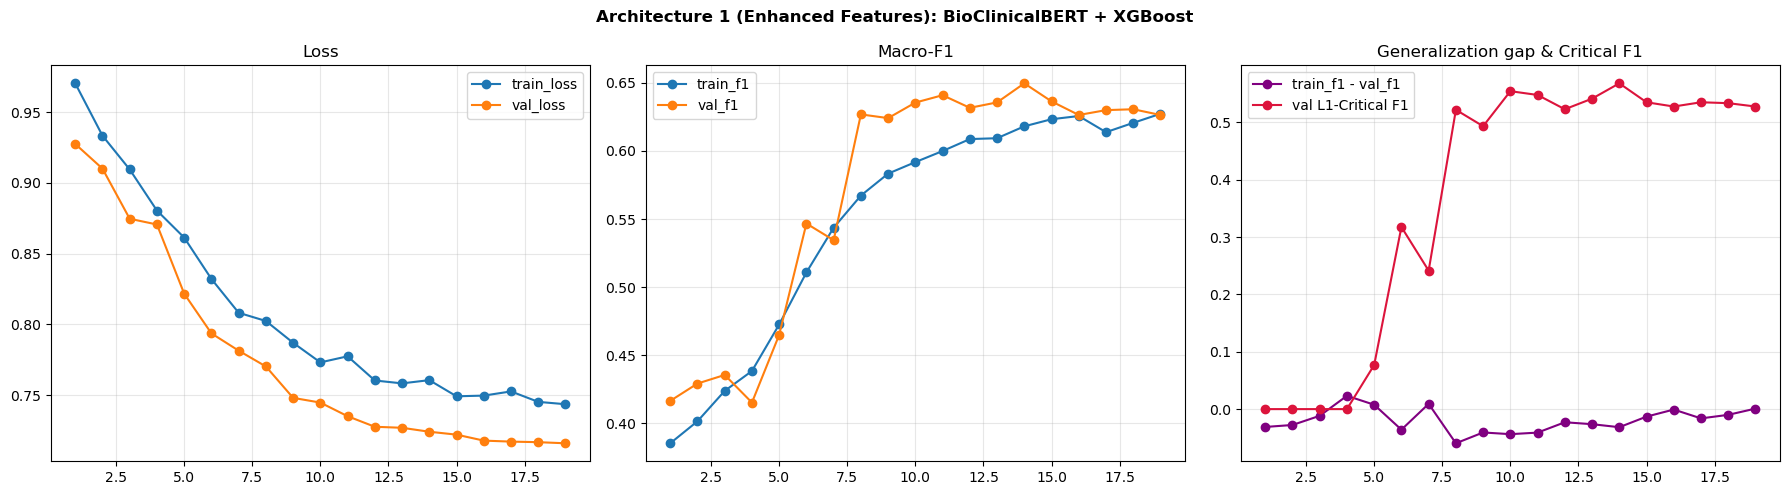

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   marker="o", label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_f1"], marker="o", label="train_f1")
axes[1].plot(history_df["epoch"], history_df["val_f1"],   marker="o", label="val_f1")
axes[1].set_title("Macro-F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["generalization_gap"], marker="o",
             color="purple", label="train_f1 - val_f1")
axes[2].plot(history_df["epoch"], history_df["val_critical_f1"],    marker="o",
             color="crimson", label="val L1-Critical F1")
axes[2].set_title("Generalization gap & Critical F1")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Architecture 1 (Enhanced Features): BioClinicalBERT + XGBoost", fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

In [17]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

val_metrics      = eval_epoch(model, val_loader,  criterion)
test_metrics     = eval_epoch(model, test_loader, criterion)
all_test_probs   = predict_probs(model, test_loader)

weighted_f1 = f1_score(y_test, test_metrics["preds"], average="weighted")
roc_auc     = roc_auc_score(y_test, all_test_probs, multi_class="ovr", average="macro")

print("Validation macro-F1:  ", round(val_metrics["macro_f1"],  4))
print("Test macro-F1:        ", round(test_metrics["macro_f1"], 4))
print("Validation critical F1:", round(val_metrics["critical_f1"],  4))
print("Test critical F1:      ", round(test_metrics["critical_f1"], 4))
print("Test weighted F1:      ", round(weighted_f1, 4))
print("Test ROC-AUC (OvR):    ", round(roc_auc, 4))
print()
print("Classification report:")
print(classification_report(
    y_test, test_metrics["preds"],
    target_names=CLASS_NAMES, zero_division=0
))

summary_df = pd.DataFrame({
    "metric": [
        "val_macro_f1", "test_macro_f1",
        "val_critical_f1", "test_critical_f1",
        "test_weighted_f1", "test_roc_auc_ovr_macro",
    ],
    "value": [
        val_metrics["macro_f1"], test_metrics["macro_f1"],
        val_metrics["critical_f1"], test_metrics["critical_f1"],
        weighted_f1, roc_auc,
    ],
})
summary_df

Validation macro-F1:   0.6496
Test macro-F1:         0.6438
Validation critical F1: 0.5679
Test critical F1:       0.5714
Test weighted F1:       0.6881
Test ROC-AUC (OvR):     0.812

Classification report:
                      precision    recall  f1-score   support

         L1-Critical       0.71      0.48      0.57        50
         L2-Emergent       0.57      0.65      0.61       310
L3-Urgent/LessUrgent       0.77      0.73      0.75       479

            accuracy                           0.69       839
           macro avg       0.68      0.62      0.64       839
        weighted avg       0.69      0.69      0.69       839



,metric,value
0,val_macro_f1,0.649591
1,test_macro_f1,0.643823
2,val_critical_f1,0.567901
3,test_critical_f1,0.571429
4,test_weighted_f1,0.688075
5,test_roc_auc_ovr_macro,0.811983


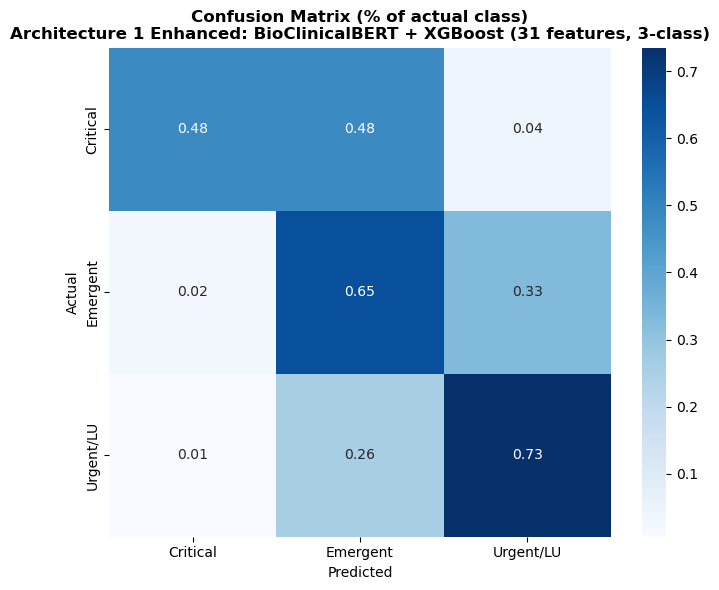


Raw confusion matrix:
                      L1-Critical  L2-Emergent  L3-Urgent/LessUrgent
L1-Critical                    24           24                     2
L2-Emergent                     7          200                   103
L3-Urgent/LessUrgent            3          124                   352


In [18]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm     = confusion_matrix(y_test, test_metrics["preds"], labels=[0, 1, 2])
cm_pct = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_pct, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=["Critical", "Emergent", "Urgent/LU"],
    yticklabels=["Critical", "Emergent", "Urgent/LU"],
)
plt.title(
    "Confusion Matrix (% of actual class)\n"
    "Architecture 1 Enhanced: BioClinicalBERT + XGBoost (31 features, 3-class)",
    fontweight="bold"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\nRaw confusion matrix:")
print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))

## 12. Save Artifacts to S3

In [ ]:
def upload_file(local_path, s3_key):
    s3.upload_file(local_path, S3_BUCKET, s3_key)
    print(f"  Uploaded → s3://{S3_BUCKET}/{s3_key}")

print(f"Saving artifacts to s3://{S3_BUCKET}/{MODEL_PREFIX}")

# 1. Fusion model weights
model_path = "/tmp/arch1_enhanced_best_model.pt"
torch.save(model.state_dict(), model_path)
upload_file(model_path, f"{MODEL_PREFIX}best_model.pt")

# 2. XGBoost fold models
for idx, fold_model in enumerate(xgb_fold_models, start=1):
    fold_path = f"/tmp/arch1_enhanced_xgb_fold{idx}.joblib"
    joblib.dump(fold_model, fold_path)
    upload_file(fold_path, f"{MODEL_PREFIX}xgb_fold{idx}.joblib")

# 3. Training history
history_path = "/tmp/arch1_enhanced_history.csv"
history_df.to_csv(history_path, index=False)
upload_file(history_path, f"{MODEL_PREFIX}history.csv")

# 4. XGBoost fold summary
fold_path = "/tmp/arch1_enhanced_xgb_fold_summary.csv"
fold_summary.to_csv(fold_path, index=False)
upload_file(fold_path, f"{MODEL_PREFIX}xgb_fold_summary.csv")

# 5. Config (features, stats, hyperparams)
config = {
    "architecture":        "arch1_enhanced_features",
    "structured_features": STRUCTURED_FEATURES,
    "n_features":          len(STRUCTURED_FEATURES),
    "n_classes":           NUM_CLASSES,
    "bert_model":          BERT_MODEL,
    "max_len":             MAX_LEN,
    "structured_stats":    structured_stats,
    "transport_map":       TRANSPORT_MAP,
    "class_weights":       [float(x) for x in CLASS_WEIGHTS.tolist()],
    "fusion_hidden_dim":   FUSION_HIDDEN_DIM,
    "fusion_dropout":      FUSION_DROPOUT,
    "unfreeze_layers":     UNFREEZE_LAYERS,
    "test_metrics": {
        "macro_f1":     round(test_metrics["macro_f1"],  4),
        "critical_f1":  round(test_metrics["critical_f1"], 4),
        "weighted_f1":  round(weighted_f1, 4),
        "roc_auc_ovr":  round(roc_auc, 4),
    },
    "best_val_f1": round(best_val_f1, 4),
}
config_path = "/tmp/arch1_enhanced_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
upload_file(config_path, f"{MODEL_PREFIX}config.json")

print()
print("All artifacts saved.")
print(f"Config: {json.dumps(config, indent=2)}")